<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Bubble Plots**


Estimated time needed: **30** minutes


In this lab, you will focus on visualizing data.

The dataset will be directly loaded into pandas for analysis and visualization.

You will use various visualization techniques to explore the data and uncover key trends.


## Objectives


In this lab, you will perform the following:


-   Visualize the distribution of data.

-   Visualize the relationship between two data features.

-   Visualize composition of data.

-   Visualize comparison of data.


#### Setup: Working with the Database
**Install and import the needed libraries**


In [165]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

**Download and connect to the database file containing survey data.**


To start, download and load the dataset into a `pandas` DataFrame.



In [166]:
# Step 1: Download the dataset
# https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv

# Load the data
df = pd.read_csv("survey_data.csv")

pd.get_option("display.max_columns", None)

# Display the first few rows of the data to understand its structure
df.head()

,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


### Task 1: Exploring Data Distributions Using Bubble Plots


#### 1. Bubble Plot for Age vs. Frequency of Participation


- Visualize the relationship between respondents’ age and their participation frequency (`SOPartFreq`) using a bubble plot.

- Use the size of the bubbles to represent their job satisfaction (`JobSat`).


In [167]:
df['SOPartFreq'].unique()

array([nan, 'Multiple times per day', 'Daily or almost daily',
       'Less than once per month or monthly', 'A few times per week',
       'A few times per month or weekly',
       'I have never participated in Q&A on Stack Overflow'], dtype=object)

In [168]:
freq_map = {
    'Less than once per month or never': 1,
    'Once per month or more': 2,
    'Once per week or more': 3,
    'A few times per week': 4,
    'Daily or almost daily': 5
}

In [169]:
##Write your code here
df['Age'].unique()

array(['Under 18 years old', '35-44 years old', '45-54 years old',
       '18-24 years old', '25-34 years old', '55-64 years old',
       'Prefer not to say', '65 years or older'], dtype=object)

In [170]:
age_map = {
    'Under 18 years old': 16,
    '18-24 years old': 21,
    '25-34 years old': 29.5,
    '34-44 years old': 39.5,
    '45-54 years old': 49.5,
    '55-64 years old': 59.5,
    '65 years or older': 70
}

In [171]:
df_bubble = df[['Age', 'SOPartFreq', 'JobSat']].dropna()

df_bubble['Age_num'] = df_bubble['Age'].map(age_map)
df_bubble['SOPartFreq_num'] = df_bubble['SOPartFreq'].map(freq_map)

df_bubble.dropna(subset=['Age_num', 'SOPartFreq'])

,Age,SOPartFreq,JobSat,Age_num,SOPartFreq_num
15,45-54 years old,A few times per month or weekly,5.0,49.5,NaN
18,25-34 years old,A few times per week,10.0,29.5,4.0
20,25-34 years old,Less than once per month or monthly,6.0,29.5,NaN
22,45-54 years old,I have never participated in Q&A on Stack Over...,9.0,49.5,NaN
27,25-34 years old,Daily or almost daily,7.0,29.5,5.0
...,...,...,...,...,...
65166,25-34 years old,Less than once per month or monthly,8.0,29.5,NaN
65178,45-54 years old,A few times per month or weekly,8.0,49.5,NaN
65241,25-34 years old,Less than once per month or monthly,5.0,29.5,NaN
65265,18-24 years old,Less than once per month or monthly,8.0,21.0,NaN


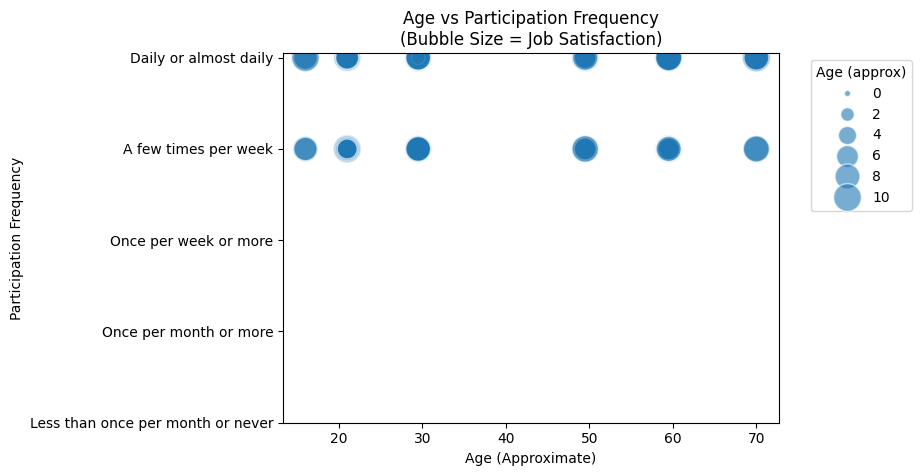

In [172]:
sns.scatterplot(
    data=df_bubble,
    x='Age_num',
    y='SOPartFreq_num',
    size='JobSat',
    sizes=(20, 400),
    alpha=0.6
)

plt.title('Age vs Participation Frequency\n(Bubble Size = Job Satisfaction)')
plt.xlabel('Age (Approximate)')
plt.ylabel('Participation Frequency')
plt.yticks(
    list(freq_map.values()),
    list(freq_map.keys())
)
plt.legend(title='Age (approx)', bbox_to_anchor=(1.05, 1), loc='upper left')

The bubble plot suggests that participation frequency tends to increase slightly with age, particularly from early to mid-career stages. Larger bubbles appear more frequently at higher participation levels, indicating that respondents who participate more actively in professional or community activities often report higher job satisfaction. However, job satisfaction varies across all age groups, suggesting that engagement is a contributing but not exclusive factor.

#### 2. Bubble Plot for Compensation vs. Job Satisfaction


-Visualize the relationship between yearly compensation (`ConvertedCompYearly`) and job satisfaction (`JobSat`).

- Use the size of the bubbles to represent respondents’ age.


In [173]:
##Write your code here
df['ConvertedCompYearly'].unique()

array([    nan,   7322.,  30074., ...,  15637.,   9711., 116844.],
      shape=(6114,))

In [174]:
df_comp_sat = df[['Age', 'JobSat', 'ConvertedCompYearly']].dropna()
df_comp_sat['Age_num'] = df_comp_sat['Age'].map(age_map)
df_comp_sat = df_comp_sat.dropna(subset='Age_num')

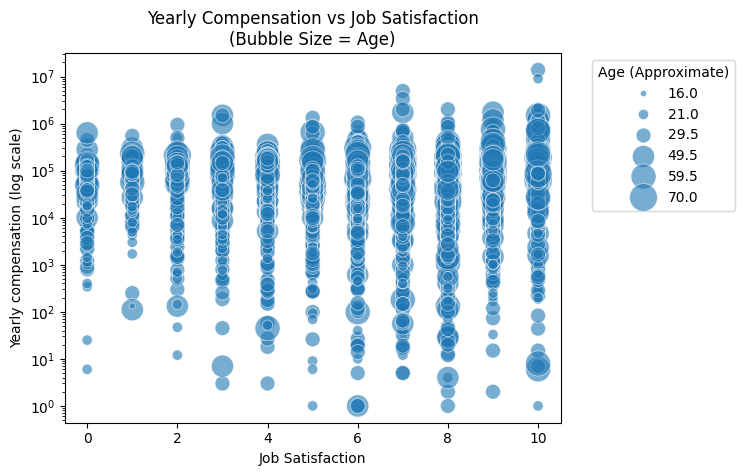

In [175]:
sns.scatterplot(
    data=df_comp_sat,
    x='JobSat',
    y='ConvertedCompYearly',
    size='Age_num',
    sizes=(20, 400),
    alpha=0.6
)
plt.yscale('log')
plt.title('Yearly Compensation vs Job Satisfaction\n(Bubble Size = Age)')
plt.xlabel('Job Satisfaction')
plt.ylabel('Yearly compensation (log scale)')
plt.legend(title='Age (Approximate)', bbox_to_anchor=(1.05, 1), loc='upper left')

The bubble plot shows that yearly compensation generally increases with job satisfaction, although the relationship is not strictly linear. Larger bubbles (older respondents) are more common at higher compensation levels, reflecting the impact of age and experience on earnings. However, job satisfaction varies across all compensation levels, suggesting that factors beyond salary influence overall satisfaction.

### Task 2: Analyzing Relationships Using Bubble Plots


#### 1. Bubble Plot of Technology Preferences by Age

- Visualize the popularity of programming languages respondents have worked with (`LanguageHaveWorkedWith`) across age groups.

- Use bubble size to represent the frequency of each language.



In [176]:
##Write your code here
df['LanguageHaveWorkedWith'].unique()

array([nan,
       'Bash/Shell (all shells);Go;HTML/CSS;Java;JavaScript;Python;TypeScript',
       'C#', ...,
       'Bash/Shell (all shells);C;C#;C++;Delphi;Groovy;HTML/CSS;Java;JavaScript;Objective-C;PowerShell;Python;SQL;Swift;TypeScript',
       'C;C++;Go;Lua;Objective-C;Python;Rust;SQL',
       'C;HTML/CSS;Java;JavaScript;PHP;Python;TypeScript'],
      shape=(23865,), dtype=object)

In [177]:
df_lang_age = df[['Age', 'LanguageHaveWorkedWith']].dropna()

df_lang_age['Age_num'] = df_lang_age['Age'].map(age_map)
df_lang_age = df_lang_age.dropna(subset=['Age_num'])
df_lang_age

,Age,LanguageHaveWorkedWith,Age_num
2,45-54 years old,C#,49.5
3,18-24 years old,C;C++;HTML/CSS;Java;JavaScript;PHP;PowerShell;...,21.0
4,18-24 years old,C++;HTML/CSS;JavaScript;Lua;Python;Rust,21.0
5,Under 18 years old,Bash/Shell (all shells);HTML/CSS;Java;JavaScri...,16.0
7,18-24 years old,HTML/CSS;JavaScript;TypeScript,21.0
...,...,...,...
65421,25-34 years old,Bash/Shell (all shells);Python,29.5
65427,25-34 years old,MATLAB;Python;SQL,29.5
65431,45-54 years old,Bash/Shell (all shells);C;C#;C++;Delphi;Groovy...,49.5
65435,18-24 years old,C;C++;Go;Lua;Objective-C;Python;Rust;SQL,21.0


In [178]:
df_lang_age['Language'] = df_lang_age['LanguageHaveWorkedWith'].str.split(';')
df_lang_age = df_lang_age.explode('Language')
df_lang_age

,Age,LanguageHaveWorkedWith,Age_num,Language
2,45-54 years old,C#,49.5,C#
3,18-24 years old,C;C++;HTML/CSS;Java;JavaScript;PHP;PowerShell;...,21.0,C
3,18-24 years old,C;C++;HTML/CSS;Java;JavaScript;PHP;PowerShell;...,21.0,C++
3,18-24 years old,C;C++;HTML/CSS;Java;JavaScript;PHP;PowerShell;...,21.0,HTML/CSS
3,18-24 years old,C;C++;HTML/CSS;Java;JavaScript;PHP;PowerShell;...,21.0,Java
...,...,...,...,...
65436,18-24 years old,C;HTML/CSS;Java;JavaScript;PHP;Python;TypeScript,21.0,Java
65436,18-24 years old,C;HTML/CSS;Java;JavaScript;PHP;Python;TypeScript,21.0,JavaScript
65436,18-24 years old,C;HTML/CSS;Java;JavaScript;PHP;Python;TypeScript,21.0,PHP
65436,18-24 years old,C;HTML/CSS;Java;JavaScript;PHP;Python;TypeScript,21.0,Python


In [179]:
lang_age_counts = (
    df_lang_age
    .groupby(['Age_num', 'Language'])
    .size()
    .reset_index(name='Count')
)
lang_age_counts

,Age_num,Language,Count
0,16.0,Ada,25
1,16.0,Apex,7
2,16.0,Assembly,242
3,16.0,Bash/Shell (all shells),746
4,16.0,C,746
...,...,...,...
289,70.0,TypeScript,63
290,70.0,VBA,96
291,70.0,Visual Basic (.Net),63
292,70.0,Zephyr,3


In [180]:
top_languages = (
    lang_age_counts.groupby('Language')['Count']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .index
)

lang_age_counts = lang_age_counts[lang_age_counts['Language'].isin(top_languages)]

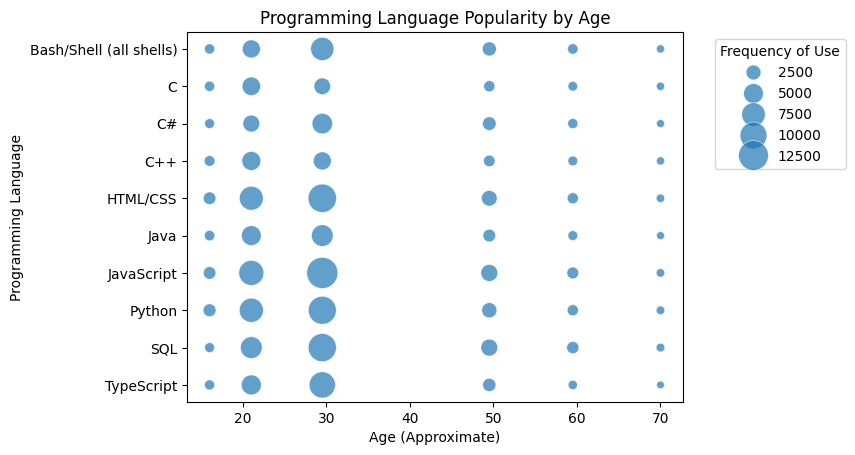

In [181]:
sns.scatterplot(
    data=lang_age_counts,
    x='Age_num',
    y='Language',
    size='Count',
    sizes=(30, 500),
    alpha=0.7
)

plt.title('Programming Language Popularity by Age')
plt.xlabel('Age (Approximate)')
plt.ylabel('Programming Language')
plt.legend(title='Frequency of Use', bbox_to_anchor=(1.05, 1), loc='upper left')


The bubble plot shows clear differences in programming language popularity across age groups. Languages such as Python, JavaScript, and SQL appear consistently popular across most age but mostly at the approximate age of 30. Larger bubbles at 20s and 30s years of age indicate higher participation and broader technology exposure among experienced respondents.

#### 2. Bubble Plot for Preferred Databases vs. Job Satisfaction

- Explore the relationship between preferred databases (`DatabaseWantToWorkWith`) and job satisfaction.

- Use bubble size to indicate the number of respondents for each database.


In [182]:
##Write your code here
df['DatabaseWantToWorkWith'].unique()

array([nan, 'PostgreSQL', 'Firebase Realtime Database', ...,
       'Cassandra;Firebase Realtime Database;MariaDB;Microsoft Access;MongoDB;MySQL;PostgreSQL;Redis',
       'MySQL;Presto;TiDB',
       'BigQuery;Cassandra;Databricks SQL;DuckDB;Elasticsearch;Firebase Realtime Database;Microsoft SQL Server;MongoDB;MySQL;PostgreSQL;Redis;Snowflake;SQLite;Supabase'],
      shape=(8479,), dtype=object)

In [183]:
df_db_sat = df[['DatabaseWantToWorkWith', 'JobSat']].dropna()

In [184]:
df_db_sat['Database'] = df_db_sat['DatabaseWantToWorkWith'].str.split(';')
df_db_sat = df_db_sat.explode('Database')
df_db_sat

,DatabaseWantToWorkWith,JobSat,Database
10,Elasticsearch;MongoDB;PostgreSQL;SQLite,8.0,Elasticsearch
10,Elasticsearch;MongoDB;PostgreSQL;SQLite,8.0,MongoDB
10,Elasticsearch;MongoDB;PostgreSQL;SQLite,8.0,PostgreSQL
10,Elasticsearch;MongoDB;PostgreSQL;SQLite,8.0,SQLite
12,MySQL,8.0,MySQL
...,...,...,...
65351,Cassandra;Firebase Realtime Database;MariaDB;M...,8.0,Microsoft Access
65351,Cassandra;Firebase Realtime Database;MariaDB;M...,8.0,MongoDB
65351,Cassandra;Firebase Realtime Database;MariaDB;M...,8.0,MySQL
65351,Cassandra;Firebase Realtime Database;MariaDB;M...,8.0,PostgreSQL


In [185]:
db_stats = (
    df_db_sat
    .groupby('Database')
    .agg(
        AvgJobSat=('JobSat', 'mean'),
        Count=('JobSat', 'size')
    )
    .reset_index()
)
db_stats.head()

,Database,AvgJobSat,Count
0,BigQuery,6.947997,1423
1,Cassandra,6.625093,1339
2,Clickhouse,6.974811,794
3,Cloud Firestore,7.154146,1025
4,Cockroachdb,6.859259,675


In [186]:
db_stats = db_stats.sort_values('Count', ascending=False).head(10)

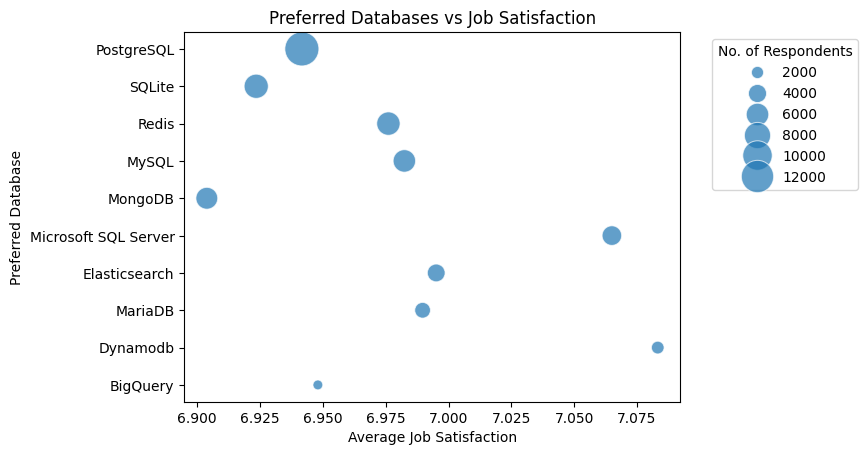

In [187]:
sns.scatterplot(
    data=db_stats,
    x='AvgJobSat',
    y='Database',
    size='Count',
    sizes=(50, 600),
    alpha=0.7
)

plt.title('Preferred Databases vs Job Satisfaction')
plt.xlabel('Average Job Satisfaction')
plt.ylabel('Preferred Database')
plt.legend(title= 'No. of Respondents', bbox_to_anchor=(1.05, 1), loc='upper left')

The bubble plot shows that widely preferred databases such as PostgreSQL, MySQL, and MongoDB have large bubbles, indicating strong popularity among respondents especially for PostgreSQL. Average job satisfaction varies moderately across databases, suggesting that while certain databases are more commonly desired, preference alone does not strongly determine job satisfaction. Some less dominant databases exhibit relatively high satisfaction, indicating potential alignment with more specialized or fulfilling roles.

### Task 3: Comparing Data Using Bubble Plots


#### 1. Bubble Plot for Compensation Across Developer Roles

- Visualize compensation (`ConvertedCompYearly`) across different developer roles (`DevType`).

- Use bubble size to represent job satisfaction.


In [188]:
##Write your code here
df['DevType'].unique()

array([nan, 'Developer, full-stack', 'Developer Experience', 'Student',
       'Academic researcher', 'Project manager', 'Developer Advocate',
       'Developer, back-end', 'Other (please specify):',
       'Developer, front-end', 'Database administrator',
       'Developer, desktop or enterprise applications',
       'Cloud infrastructure engineer',
       'Data scientist or machine learning specialist',
       'Research & Development role',
       'Developer, embedded applications or devices',
       'System administrator', 'DevOps specialist', 'Engineering manager',
       'Designer', 'Security professional',
       'Senior Executive (C-Suite, VP, etc.)', 'Developer, mobile',
       'Developer, game or graphics', 'Data or business analyst',
       'Educator', 'Developer, QA or test', 'Product manager',
       'Developer, AI', 'Scientist', 'Engineer, site reliability',
       'Blockchain', 'Marketing or sales professional',
       'Hardware Engineer', 'Data engineer'], dtype=object)

In [189]:
df['ConvertedCompYearly'].unique()

array([    nan,   7322.,  30074., ...,  15637.,   9711., 116844.],
      shape=(6114,))

In [190]:
df['JobSat'].unique()

array([nan,  8.,  5., 10.,  6.,  9.,  4.,  7.,  3.,  2.,  1.,  0.])

In [191]:
df_dev_comp = df[['DevType', 'ConvertedCompYearly', 'JobSat']].dropna()

In [192]:
dev_stats = (
    df_dev_comp
    .groupby('DevType')
    .agg(
        MedianComp=('ConvertedCompYearly', 'median'),
        AvgJobSat=('JobSat', 'mean'),
        Count=('JobSat', 'size')
    )
    .reset_index()
)
dev_stats.head()

,DevType,MedianComp,AvgJobSat,Count
0,Academic researcher,48370.0,6.781250,224
1,Blockchain,110966.5,7.620690,58
2,Cloud infrastructure engineer,100000.0,6.897436,195
3,Data engineer,73218.5,6.682741,394
4,Data or business analyst,55121.5,6.059322,118


In [193]:
dev_stats = dev_stats.sort_values('Count', ascending=False).head(20)

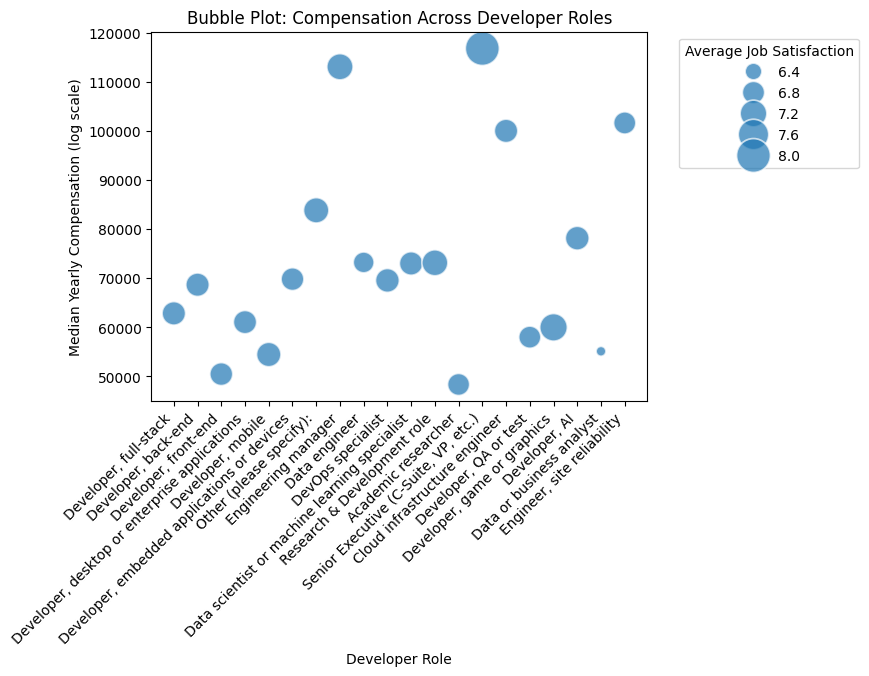

In [194]:
sns.scatterplot(
    data=dev_stats,
    x='DevType',
    y='MedianComp',
    size='AvgJobSat',
    sizes=(50, 600),
    alpha=0.7
)

plt.title('Bubble Plot: Compensation Across Developer Roles')
plt.xlabel('Developer Role')
plt.ylabel('Median Yearly Compensation (log scale)')
plt.xticks(rotation=45, ha='right')

plt.legend(title='Average Job Satisfaction', bbox_to_anchor=(1.05, 1), loc='upper left')

The bubble plot shows clear differences in compensation across developer roles. Senior and specialized roles such as backend developers, data scientists, and DevOps specialists tend to have higher median compensation. Larger bubbles among these roles indicate relatively higher job satisfaction, while some lower-paid roles exhibit smaller bubbles, suggesting more modest satisfaction levels. This highlights the combined influence of role specialization on both earnings and job satisfaction.

#### 2. Bubble Plot for Collaboration Tools by Age

- Visualize the relationship between the collaboration tools used (`NEWCollabToolsHaveWorkedWith`) and age groups.

- Use bubble size to represent the frequency of tool usage.


In [195]:
##Write your code here
df['NEWCollabToolsHaveWorkedWith'].unique()

array([nan, 'PyCharm;Visual Studio Code;WebStorm', 'Visual Studio', ...,
       'Android Studio;IntelliJ IDEA;Jupyter Notebook/JupyterLab;Neovim;PyCharm;Visual Studio Code',
       'PhpStorm;RubyMine;Vim;Visual Studio Code;WebStorm',
       'DataGrip;IntelliJ IDEA;PyCharm;Rider;Sublime Text;Vim;Visual Studio;Visual Studio Code;WebStorm;Xcode'],
      shape=(14169,), dtype=object)

In [196]:
age_map = {
    'Under 18 years old': 16,
    '18-24 years old': 21,
    '25-34 years old': 29.5,
    '35-44 years old': 39.5,
    '45-54 years old': 49.5,
    '55-64 years old': 59.5,
    '65 years or older': 70
}

df_collab_age = df[['Age', 'NEWCollabToolsHaveWorkedWith']].dropna()

df_collab_age['Age_num'] = df_collab_age['Age'].map(age_map)
df_collab_age = df_collab_age.dropna(subset=['Age_num'])

In [197]:
df_collab_age['Tool'] = df_collab_age['NEWCollabToolsHaveWorkedWith'].str.split(';')
df_collab_age = df_collab_age.explode('Tool')
df_collab_age

,Age,NEWCollabToolsHaveWorkedWith,Age_num,Tool
1,35-44 years old,PyCharm;Visual Studio Code;WebStorm,39.5,PyCharm
1,35-44 years old,PyCharm;Visual Studio Code;WebStorm,39.5,Visual Studio Code
1,35-44 years old,PyCharm;Visual Studio Code;WebStorm,39.5,WebStorm
2,45-54 years old,Visual Studio,49.5,Visual Studio
4,18-24 years old,Vim,21.0,Vim
...,...,...,...,...
65431,45-54 years old,DataGrip;IntelliJ IDEA;PyCharm;Rider;Sublime T...,49.5,WebStorm
65431,45-54 years old,DataGrip;IntelliJ IDEA;PyCharm;Rider;Sublime T...,49.5,Xcode
65435,18-24 years old,Vim;Visual Studio Code,21.0,Vim
65435,18-24 years old,Vim;Visual Studio Code,21.0,Visual Studio Code


In [198]:
tool_age_counts = (
    df_collab_age
    .groupby(['Age_num', 'Tool'])
    .size()
    .reset_index(name='Count')
)

In [199]:
top_tools = (
    tool_age_counts.groupby('Tool')['Count']
    .sum()
    .sort_values(ascending=False)
    .head(30)
    .index
)

tool_age_counts = tool_age_counts[tool_age_counts['Tool'].isin(top_tools)]

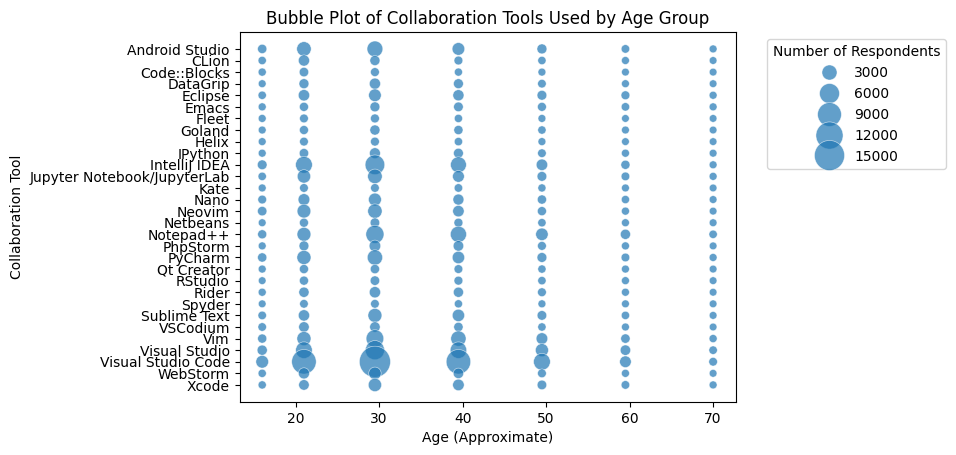

In [200]:
sns.scatterplot(
    data=tool_age_counts,
    x='Age_num',
    y='Tool',
    size='Count',
    sizes=(30, 500),
    alpha=0.7
)

plt.title('Bubble Plot of Collaboration Tools Used by Age Group')
plt.xlabel('Age (Approximate)')
plt.ylabel('Collaboration Tool')

plt.legend(
    title='Number of Respondents',
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)

The bubble plot shows that tools such as Visual Studio Code, PyCharm, and IntelliJ IDEA are widely used across all age groups, with particularly high adoption among mid-career respondents. Younger age groups tend to concentrate around fewer tools, while older respondents display broader tool usage, reflecting accumulated experience and exposure to multiple development environments.

### Task 4: Visualizing Technology Trends Using Bubble Plots


#### 1. Bubble Plot for Preferred Web Frameworks vs. Job Satisfaction

- Explore the relationship between preferred web frameworks (`WebframeWantToWorkWith`) and job satisfaction.

- Use bubble size to represent the number of respondents.



In [201]:
##Write your code here
df['WebframeWantToWorkWith'].unique()

array([nan, 'Express;Htmx;Node.js;React;Remix', 'ASP.NET CORE', ...,
       'Deno;Express;Fastify;Flask;NestJS;Node.js',
       'ASP.NET;Laravel;React;Spring Boot',
       'Django;Express;Laravel;NestJS;Next.js;Node.js;Nuxt.js;React;Spring Boot;Symfony;Vue.js;WordPress'],
      shape=(11655,), dtype=object)

In [202]:
df_web_age = df[['WebframeWantToWorkWith', 'JobSat']].dropna()
df_web_age['Framework'] = df_web_age['WebframeWantToWorkWith'].str.split(';')
df_web_age = df_web_age.explode('Framework')
df_web_age

,WebframeWantToWorkWith,JobSat,Framework
10,Django;Node.js;React;Ruby on Rails,8.0,Django
10,Django;Node.js;React;Ruby on Rails,8.0,Node.js
10,Django;Node.js;React;Ruby on Rails,8.0,React
10,Django;Node.js;React;Ruby on Rails,8.0,Ruby on Rails
15,Blazor,5.0,Blazor
...,...,...,...
65351,Django;Express;Laravel;NestJS;Next.js;Node.js;...,8.0,React
65351,Django;Express;Laravel;NestJS;Next.js;Node.js;...,8.0,Spring Boot
65351,Django;Express;Laravel;NestJS;Next.js;Node.js;...,8.0,Symfony
65351,Django;Express;Laravel;NestJS;Next.js;Node.js;...,8.0,Vue.js


In [203]:
web_stats = (
    df_web_age
    .groupby('Framework')
    .agg(
        AvgJobSat=('JobSat', 'mean'),
        Count=('JobSat', 'size')
    )
    .reset_index()
)


In [204]:
top_frameworks = web_stats.sort_values('Count', ascending=False).head(30)['Framework']
web_stats = web_stats[web_stats['Framework'].isin(top_frameworks)]

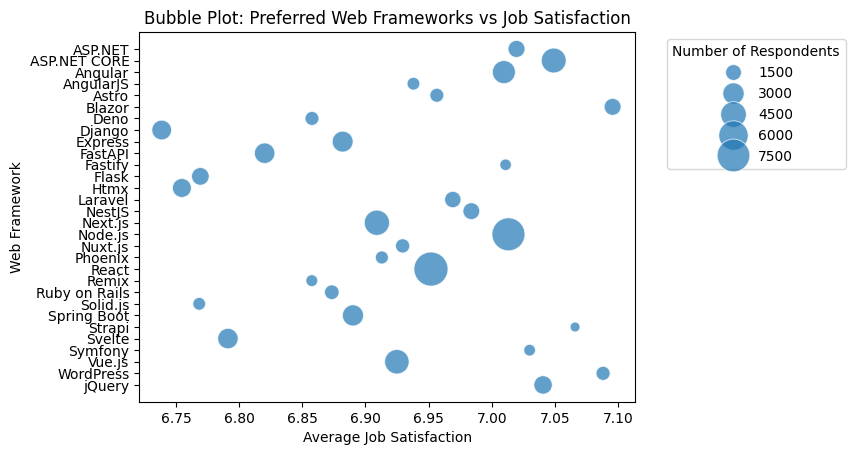

In [205]:
sns.scatterplot(
    data=web_stats,
    x='AvgJobSat',
    y='Framework',
    size='Count',
    sizes=(50, 600),
    alpha=0.7
)

plt.title('Bubble Plot: Preferred Web Frameworks vs Job Satisfaction')
plt.xlabel('Average Job Satisfaction')
plt.ylabel('Web Framework')

plt.legend(
    title='Number of Respondents',
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)

The bubble plot shows that popular frameworks like React, Node JS, and Asp.net core are used by many respondents, represented by larger bubbles. Average job satisfaction is fairly uniform across frameworks, although some smaller frameworks show slightly higher satisfaction, indicating respondents may find niche frameworks more fulfilling or aligned with their work preferences.

#### 2. Bubble Plot for Admired Technologies Across Countries

- Visualize the distribution of admired technologies (`LanguageAdmired`) across different countries (`Country`).

- Use bubble size to represent the frequency of admiration.



In [206]:
##Write your code here
df['LanguageAdmired'].unique()

array([nan,
       'Bash/Shell (all shells);Go;HTML/CSS;Java;JavaScript;Python;TypeScript',
       'C#', ..., 'Elixir;Lua;Python;Ruby;SQL',
       'Bash/Shell (all shells);C;C++;HTML/CSS;Java;JavaScript;PowerShell;Rust;Solidity;SQL;TypeScript;VBA;Visual Basic (.Net)',
       'Bash/Shell (all shells);C#;HTML/CSS;Java;JavaScript;Objective-C;Python;SQL;Swift;TypeScript'],
      shape=(12336,), dtype=object)

In [207]:
df_lang_admired = df[['Country', 'LanguageAdmired']].dropna()

In [208]:
df_lang_admired['Technology'] = df_lang_admired['LanguageAdmired'].str.split(';')
df_lang_admired = df_lang_admired.explode('Technology')
df_lang_admired

,Country,LanguageAdmired,Technology
1,United Kingdom of Great Britain and Northern I...,Bash/Shell (all shells);Go;HTML/CSS;Java;JavaS...,Bash/Shell (all shells)
1,United Kingdom of Great Britain and Northern I...,Bash/Shell (all shells);Go;HTML/CSS;Java;JavaS...,Go
1,United Kingdom of Great Britain and Northern I...,Bash/Shell (all shells);Go;HTML/CSS;Java;JavaS...,HTML/CSS
1,United Kingdom of Great Britain and Northern I...,Bash/Shell (all shells);Go;HTML/CSS;Java;JavaS...,Java
1,United Kingdom of Great Britain and Northern I...,Bash/Shell (all shells);Go;HTML/CSS;Java;JavaS...,JavaScript
...,...,...,...
65431,Belgium,Bash/Shell (all shells);C#;HTML/CSS;Java;JavaS...,SQL
65431,Belgium,Bash/Shell (all shells);C#;HTML/CSS;Java;JavaS...,Swift
65431,Belgium,Bash/Shell (all shells);C#;HTML/CSS;Java;JavaS...,TypeScript
65435,Germany,Rust;SQL,Rust


In [212]:
tech_country_counts = (
    df_lang_admired
    .groupby(['Country', 'Technology'])
    .size()
    .reset_index(name='Count')
)

In [ ]:
top_countries = df_lang_admired['Country'].value_counts().head(30).index

top_techs = (
    tech_country_counts.groupby('Technology')['Count']
    .sum()
    .sort_values(ascending=False)
    .head(30)
    .index
)

# Filtering the dataset to include only top countries AND top technologies
tech_country_counts_filtered = tech_country_counts[
    (tech_country_counts['Country'].isin(top_countries)) &
    (tech_country_counts['Technology'].isin(top_techs))
]


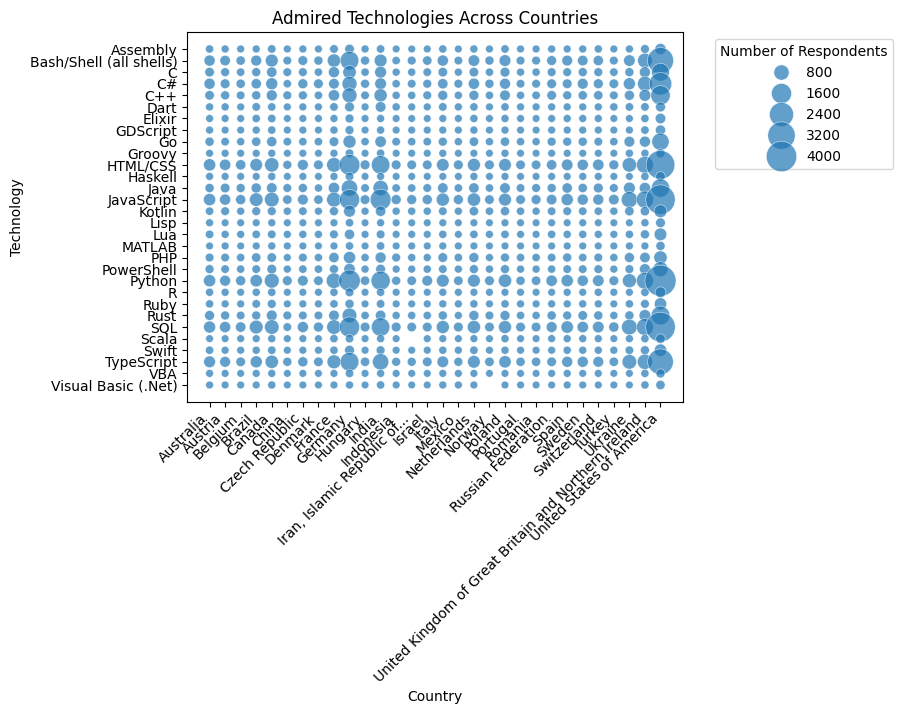

In [215]:
sns.scatterplot(
    data=tech_country_counts_filtered,
    x='Country',
    y='Technology',
    size='Count',
    sizes=(30, 500),
    alpha=0.7
)

plt.title('Admired Technologies Across Countries')
plt.xlabel('Country')
plt.ylabel('Technology')
plt.xticks(rotation=45, ha='right')

plt.legend(
    title='Number of Respondents',
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)

The bubble plot reveals which programming languages or technologies are most admired in different countries, USA having higher adminration for majority of languages. Technologies like Python, JavaScript, and SQL appear as large bubbles across multiple countries, indicating widespread admiration. Some niche technologies show strong admiration in specific countries, highlighting regional trends in developer preferences.

## Final Step: Review


After completing the lab, you will have extensively used bubble plots to gain insights into developer community preferences, demographics, compensation trends, and job satisfaction.


## Summary


After completing this lab, you will be able to:

- Create and interpret bubble plots to analyze relationships and compositions within datasets.

- Use bubble plots to explore developer preferences, compensation trends, and satisfaction levels.

- Apply bubble plots to visualize complex relationships involving multiple dimensions effectively.


## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


<!--
## Change Log
|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|
|2024-10-29|1.2|Madhusudhan Moole|Updated lab|
|2024-10-16|1.1|Madhusudhan Moole|Updated lab|
|2024-10-15|1.0|Raghul Ramesh|Created lab|
--!>


Copyright © IBM Corporation. All rights reserved.
